In [ ]:
import pandas as pd

app = pd.read_csv("application_train.csv")
prev = pd.read_csv("previous_application.csv")
bureau = pd.read_csv("bureau.csv")
installments = pd.read_csv("installments_payments.csv")

print(app.shape)


In [ ]:
cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "DAYS_EMPLOYED",
    "AMT_ANNUITY",
    "AMT_CREDIT"
]

app = pd.read_csv("application_train.csv", usecols=cols)


In [ ]:
import os
os.listdir()


In [ ]:
cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "DAYS_EMPLOYED",
    "AMT_ANNUITY",
    "AMT_CREDIT"
]

app = pd.read_csv("application_train.csv", usecols=cols)

print(app.shape)


In [ ]:
app["income_bucket"] = pd.qcut(
    app["AMT_INCOME_TOTAL"],
    5,
    labels=False,
    duplicates="drop"
)


In [ ]:
app["employment_type"] = app["NAME_INCOME_TYPE"].astype("category").cat.codes


In [ ]:
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365

app["employment_bucket"] = pd.cut(
    app["employment_years"],
    bins=[0,0.5,1,3,50],
    labels=[0,1,2,3]
)


In [ ]:
app["emi_ratio"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]


In [ ]:
app["credit_income_ratio"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]


In [ ]:
app["risk_index"] = (
    app["emi_ratio"] +
    app["credit_income_ratio"]
)


In [ ]:
features = [
    "income_bucket",
    "employment_type",
    "employment_bucket",
    "emi_ratio",
    "credit_income_ratio",
    "risk_index"
]

X = app[features].fillna(0)
y = app["TARGET"]

print(X.head())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
app["employment_bucket"] = app["employment_bucket"].astype(int)


In [ ]:
X = app[features].fillna(0)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
print(X.dtypes)



In [ ]:
X = X.copy()

for col in X.columns:
    if X[col].dtype == "category":
        X[col] = X[col].astype(int)

X = X.astype(float)


In [ ]:
print(X.dtypes)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
installments = pd.read_csv("installments_payments.csv")


In [ ]:
installments["late_payment"] = (
    installments["DAYS_ENTRY_PAYMENT"] >
    installments["DAYS_INSTALMENT"]
).astype(int)


In [ ]:
late_rate = installments.groupby("SK_ID_CURR")["late_payment"].mean()


In [ ]:
app = app.merge(late_rate, on="SK_ID_CURR", how="left")
app["late_payment"].fillna(0, inplace=True)


In [ ]:
app["late_payment"] = app["late_payment"].fillna(0)


In [ ]:
app["CREDIT_DAY_OVERDUE"] = app["CREDIT_DAY_OVERDUE"].fillna(0)
app["rejected"] = app["rejected"].fillna(0)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
print(app.columns)


In [ ]:
cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "DAYS_EMPLOYED",
    "AMT_ANNUITY",
    "AMT_CREDIT"
]

app = pd.read_csv("application_train.csv", usecols=cols)


In [ ]:
# Installments
installments = pd.read_csv("installments_payments.csv")

installments["late_payment"] = (
    installments["DAYS_ENTRY_PAYMENT"] >
    installments["DAYS_INSTALMENT"]
).astype(int)

late_rate = installments.groupby("SK_ID_CURR")["late_payment"].mean()

app = app.merge(late_rate, on="SK_ID_CURR", how="left")


# Bureau
bureau = pd.read_csv("bureau.csv")

max_overdue = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].max()

app = app.merge(max_overdue, on="SK_ID_CURR", how="left")


# Previous Applications
prev = pd.read_csv("previous_application.csv")

prev["rejected"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)

rejection_count = prev.groupby("SK_ID_CURR")["rejected"].sum()

app = app.merge(rejection_count, on="SK_ID_CURR", how="left")


In [ ]:
app["late_payment"] = app["late_payment"].fillna(0)
app["CREDIT_DAY_OVERDUE"] = app["CREDIT_DAY_OVERDUE"].fillna(0)
app["rejected"] = app["rejected"].fillna(0)


In [ ]:
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365
app["employment_bucket"] = pd.cut(
    app["employment_years"], bins=[0,0.5,1,3,50]
).cat.codes

app["income_bucket"] = pd.qcut(
    app["AMT_INCOME_TOTAL"], 5, labels=False, duplicates="drop"
)

app["employment_type"] = app["NAME_INCOME_TYPE"].astype("category").cat.codes

app["emi_ratio"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]
app["credit_income_ratio"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]


In [ ]:
features = [
    "income_bucket",
    "employment_type",
    "employment_bucket",
    "emi_ratio",
    "credit_income_ratio",
    "late_payment",
    "CREDIT_DAY_OVERDUE",
    "rejected"
]

X = app[features].fillna(0).astype(float)
y = app["TARGET"]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scale_weight = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=scale_weight,
    eval_metric="auc"
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
installments = pd.read_csv("installments_payments.csv")

installments["late"] = (
    installments["DAYS_ENTRY_PAYMENT"] >
    installments["DAYS_INSTALMENT"]
).astype(int)

# total installments count
inst_count = installments.groupby("SK_ID_CURR").size()

# late count
late_count = installments.groupby("SK_ID_CURR")["late"].sum()

# late ratio
late_ratio = late_count / inst_count

# average delay days
installments["delay_days"] = (
    installments["DAYS_ENTRY_PAYMENT"] -
    installments["DAYS_INSTALMENT"]
)

avg_delay = installments.groupby("SK_ID_CURR")["delay_days"].mean()

app = app.merge(late_ratio.rename("late_ratio"), on="SK_ID_CURR", how="left")
app = app.merge(avg_delay.rename("avg_delay"), on="SK_ID_CURR", how="left")

app["late_ratio"] = app["late_ratio"].fillna(0)
app["avg_delay"] = app["avg_delay"].fillna(0)


In [ ]:
bureau = pd.read_csv("bureau.csv")

# total loans
loan_count = bureau.groupby("SK_ID_CURR").size()

# total overdue days
total_overdue = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].sum()

# number of overdue records
overdue_flag = bureau["CREDIT_DAY_OVERDUE"] > 0
overdue_count = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].apply(lambda x: (x > 0).sum())

app = app.merge(loan_count.rename("loan_count"), on="SK_ID_CURR", how="left")
app = app.merge(total_overdue.rename("total_overdue"), on="SK_ID_CURR", how="left")
app = app.merge(overdue_count.rename("overdue_count"), on="SK_ID_CURR", how="left")

app[["loan_count","total_overdue","overdue_count"]] = \
    app[["loan_count","total_overdue","overdue_count"]].fillna(0)


In [ ]:
features = [
    "income_bucket",
    "employment_type",
    "employment_bucket",
    "emi_ratio",
    "credit_income_ratio",
    "late_ratio",
    "avg_delay",
    "loan_count",
    "total_overdue",
    "overdue_count",
    "rejected"
]

X = app[features].fillna(0).astype(float)
y = app["TARGET"]


In [ ]:
scale_weight = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    eval_metric="auc"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
extra_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]


In [ ]:
app["age_years"] = abs(app["DAYS_BIRTH"]) / 365
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365


In [ ]:
cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "DAYS_EMPLOYED",
    "DAYS_BIRTH",          # add this
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "EXT_SOURCE_1",        # add this
    "EXT_SOURCE_2",        # add this
    "EXT_SOURCE_3"         # add this
]

app = pd.read_csv("application_train.csv", usecols=cols)


In [ ]:
app["age_years"] = abs(app["DAYS_BIRTH"]) / 365
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365


In [ ]:
import pandas as pd
import numpy as np

cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "NAME_INCOME_TYPE",
    "DAYS_EMPLOYED",
    "DAYS_BIRTH",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

app = pd.read_csv("application_train.csv", usecols=cols)

print(app.shape)


In [ ]:
# Age
app["age_years"] = abs(app["DAYS_BIRTH"]) / 365

# Employment duration
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365

# Income buckets
app["income_bucket"] = pd.qcut(
    app["AMT_INCOME_TOTAL"],
    5,
    labels=False,
    duplicates="drop"
)

# Employment type encoding
app["employment_type"] = app["NAME_INCOME_TYPE"].astype("category").cat.codes

# EMI ratio
app["emi_ratio"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]

# Credit ratio
app["credit_income_ratio"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]


In [ ]:
features = [
    "income_bucket",
    "employment_type",
    "age_years",
    "employment_years",
    "emi_ratio",
    "credit_income_ratio",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

X = app[features]
y = app["TARGET"]

# Fill missing values
X = X.fillna(0)

# Convert to float for safety
X = X.astype(float)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scale_weight = (y == 0).sum() / (y == 1).sum()


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, preds))


In [ ]:
prob_default = model.predict_proba(X)[:,1]

app["credit_score"] = 300 + (1 - prob_default) * 600

print(app["credit_score"].describe())


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.model_selection import cross_val_score
import numpy as np


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoostBest": model,  # your trained xgb model
    "KNN": KNeighborsClassifier(n_neighbors=10)
}


In [ ]:
results = []

for name, clf in models.items():

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    cv_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")

    results.append([
        name,
        round(accuracy,3),
        round(precision,3),
        round(recall,3),
        round(f1,3),
        round(auc,3),
        f"{round(cv_scores.mean(),3)} ± {round(cv_scores.std(),3)}"
    ])


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1","AUC","CV Mean ± Std"]
)

print(comparison_df)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, clf in models.items():
    proba = clf.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [ ]:
for name, clf in models.items():

    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:,1]

    preds = (proba > 0.3).astype(int)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    print(name, "AUC:", round(auc,3))


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGBoostBest": model,  
    "KNN": KNeighborsClassifier(n_neighbors=10)
}


In [ ]:
precision_score(y_test, preds)


In [ ]:
proba = clf.predict_proba(X_test)[:,1]
preds = (proba > 0.3).astype(int)


In [ ]:
for name, clf in models.items():

    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:,1]

    preds = (proba > 0.3).astype(int)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    print(name, "AUC:", round(auc,3))


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Train
model.fit(X_train, y_train)

# Predict probability
proba = model.predict_proba(X_test)[:, 1]

print("Proba shape:", proba.shape)
print("Unique labels in y_test:", np.unique(y_test))

auc = roc_auc_score(y_test, proba)
print("AUC:", auc)


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scale_weight = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    eval_metric="auc",
    random_state=42
)

print("Training XGBoost...")
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:,1]
print("Final AUC:", roc_auc_score(y_test, proba))


In [1]:
import pandas as pd
import numpy as np

cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "NAME_INCOME_TYPE"
]

app = pd.read_csv("application_train.csv", usecols=cols)

print(app.shape)


(307511, 10)


In [2]:
# Age
app["age"] = abs(app["DAYS_BIRTH"]) / 365

# Employment duration
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365

# Ratios
app["credit_income_ratio"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]
app["emi_income_ratio"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]

# Encode employment type
app["income_type_encoded"] = app["NAME_INCOME_TYPE"].astype("category").cat.codes


In [1]:
import pandas as pd
import numpy as np

app_cols = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "NAME_INCOME_TYPE"
]

app = pd.read_csv("application_train.csv", usecols=app_cols)

print("App loaded:", app.shape)


App loaded: (307511, 11)


In [2]:
bureau = pd.read_csv("bureau.csv")

# Total previous loans
loan_count = bureau.groupby("SK_ID_CURR").size()

# Total overdue days
total_overdue = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].sum()

# Overdue loan count
overdue_count = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].apply(lambda x: (x > 0).sum())

app = app.merge(loan_count.rename("loan_count"), on="SK_ID_CURR", how="left")
app = app.merge(total_overdue.rename("total_overdue"), on="SK_ID_CURR", how="left")
app = app.merge(overdue_count.rename("overdue_count"), on="SK_ID_CURR", how="left")

app[["loan_count","total_overdue","overdue_count"]] = \
    app[["loan_count","total_overdue","overdue_count"]].fillna(0)

print("Bureau merged")


Bureau merged


In [3]:
installments = pd.read_csv("installments_payments.csv")

installments["late"] = (
    installments["DAYS_ENTRY_PAYMENT"] >
    installments["DAYS_INSTALMENT"]
).astype(int)

late_ratio = installments.groupby("SK_ID_CURR")["late"].mean()

installments["delay"] = (
    installments["DAYS_ENTRY_PAYMENT"] -
    installments["DAYS_INSTALMENT"]
)

avg_delay = installments.groupby("SK_ID_CURR")["delay"].mean()

app = app.merge(late_ratio.rename("late_ratio"), on="SK_ID_CURR", how="left")
app = app.merge(avg_delay.rename("avg_delay"), on="SK_ID_CURR", how="left")

app[["late_ratio","avg_delay"]] = \
    app[["late_ratio","avg_delay"]].fillna(0)

print("Installments merged")


Installments merged


In [4]:
# Age
app["age"] = abs(app["DAYS_BIRTH"]) / 365

# Employment years
app["employment_years"] = abs(app["DAYS_EMPLOYED"]) / 365

# Ratios
app["credit_income_ratio"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]
app["emi_income_ratio"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]

# Encode employment type
app["income_type_encoded"] = app["NAME_INCOME_TYPE"].astype("category").cat.codes


In [5]:
features = [
    "age",
    "employment_years",
    "credit_income_ratio",
    "emi_income_ratio",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "income_type_encoded",
    "loan_count",
    "total_overdue",
    "overdue_count",
    "late_ratio",
    "avg_delay"
]

X = app[features].fillna(0)
y = app["TARGET"]

print("Final dataset:", X.shape)


Final dataset: (307511, 13)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scale_weight = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",      # FAST
    n_jobs=-1,
    scale_pos_weight=scale_weight,
    eval_metric="auc",
    random_state=42
)

print("Training model...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

proba = model.predict_proba(X_test)[:,1]

print("FINAL AUC:", roc_auc_score(y_test, proba))


Training model...
[0]	validation_0-auc:0.68795
[50]	validation_0-auc:0.74180
[100]	validation_0-auc:0.74595
[150]	validation_0-auc:0.74736
[200]	validation_0-auc:0.74780
[250]	validation_0-auc:0.74784
[299]	validation_0-auc:0.74767
FINAL AUC: 0.7476743331545009


In [7]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [8]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


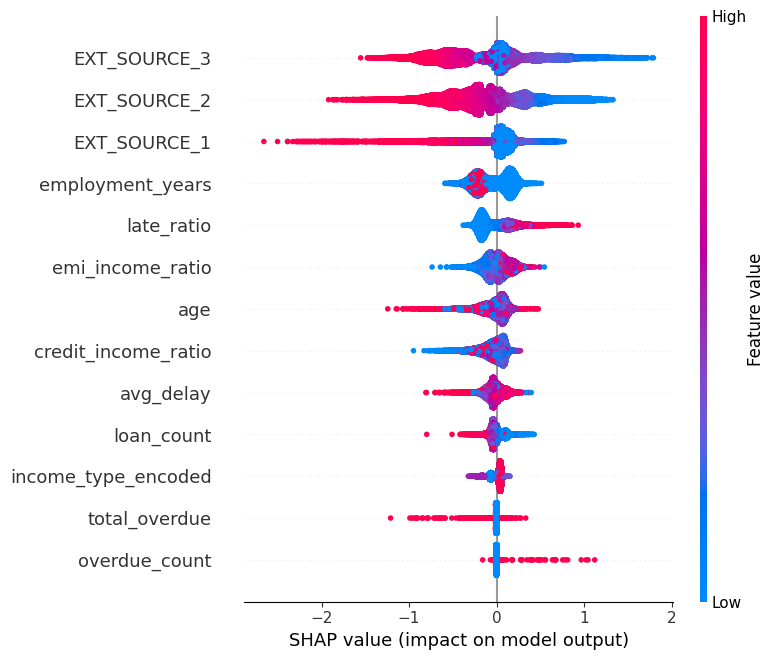

In [9]:
shap.summary_plot(shap_values, X_test)


In [10]:
prob_default_full = model.predict_proba(X)[:,1]

app["credit_score"] = 300 + (1 - prob_default_full) * 600

print(app["credit_score"].describe())


count    307511.000000
mean        657.721924
std         122.484947
min         308.698792
25%         566.243713
50%         670.694702
75%         757.554382
max         897.735046
Name: credit_score, dtype: float64


In [11]:
list(df.columns)


NameError: name 'df' is not defined

In [12]:
print(df.columns)


NameError: name 'df' is not defined

In [13]:
print(app.columns)


Index(['SK_ID_CURR', 'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'NAME_INCOME_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'loan_count', 'total_overdue',
       'overdue_count', 'late_ratio', 'avg_delay', 'age', 'employment_years',
       'credit_income_ratio', 'emi_income_ratio', 'income_type_encoded',
       'credit_score'],
      dtype='object')


In [14]:
def risk_category(score):
    if score >= 750:
        return "Prime"
    elif score >= 650:
        return "Near Prime"
    elif score >= 550:
        return "Subprime"
    else:
        return "High Risk"

app["risk_band"] = app["credit_score"].apply(risk_category)


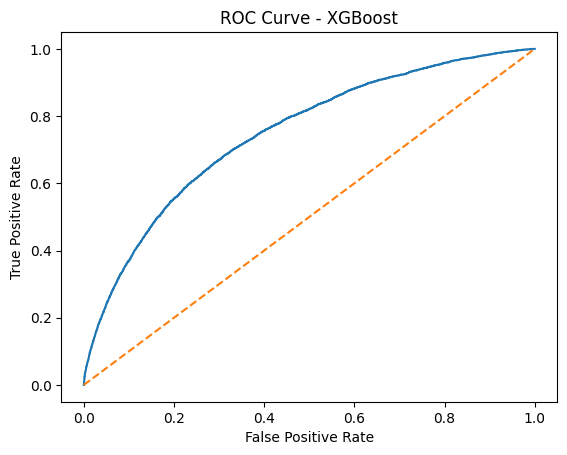

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


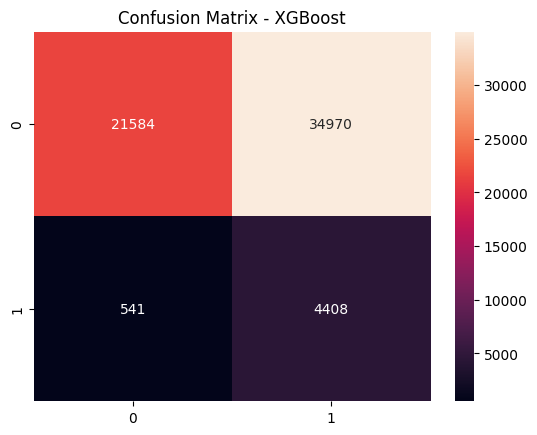

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

threshold = 0.3
preds = (proba > threshold).astype(int)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [17]:
region = pd.read_csv(
    "application_train.csv",
    usecols=["SK_ID_CURR", "REGION_RATING_CLIENT"]
)

app = app.merge(region, left_index=True, right_index=True)


In [18]:
threshold = 0.3

proba = model.predict_proba(X_test)[:,1]
preds = (proba > threshold).astype(int)

evaluation_df = X_test.copy()
evaluation_df["actual"] = y_test.values
evaluation_df["predicted"] = preds
evaluation_df["proba"] = proba
evaluation_df["region"] = app.loc[X_test.index, "REGION_RATING_CLIENT"]


In [19]:
approval_rates = evaluation_df.groupby("region")["predicted"].apply(
    lambda x: (x == 0).mean()
)

print("Approval Rates:")
print(approval_rates)


Approval Rates:
region
1    0.543963
2    0.358484
3    0.242305
Name: predicted, dtype: float64


In [20]:
dir_value = approval_rates.min() / approval_rates.max()

print("Disparate Impact Ratio:", round(dir_value,3))


Disparate Impact Ratio: 0.445


In [21]:
from sklearn.metrics import accuracy_score

subgroup_accuracy = {}

for group in evaluation_df["region"].unique():
    group_df = evaluation_df[evaluation_df["region"] == group]
    subgroup_accuracy[group] = accuracy_score(
        group_df["actual"],
        group_df["predicted"]
    )

print("Subgroup Accuracy:")
print(subgroup_accuracy)


Subgroup Accuracy:
{np.int64(2): 0.4185795479578799, np.int64(3): 0.3422116281479946, np.int64(1): 0.5710526315789474}


In [22]:
fairness_results = pd.DataFrame({
    "Approval Rate": approval_rates,
    "Accuracy": pd.Series(subgroup_accuracy)
})

fairness_results["Bias Flag"] = np.where(
    fairness_results["Approval Rate"] < (approval_rates.mean() - 0.05),
    "Flagged",
    "Pass"
)

print(fairness_results)


   Approval Rate  Accuracy Bias Flag
1       0.543963  0.571053      Pass
2       0.358484  0.418580      Pass
3       0.242305  0.342212   Flagged


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


TN: 21584
FP: 34970
FN: 541
TP: 4408


In [24]:
loss_false_negative = fn * opportunity_cost
loss_false_positive = fp * loss_per_default
revenue_true_positive = tp * profit_per_good

net_impact = revenue_true_positive - loss_false_positive - loss_false_negative

print("Loss from FN:", loss_false_negative)
print("Loss from FP:", loss_false_positive)
print("Revenue from TP:", revenue_true_positive)
print("Net Impact:", net_impact)


NameError: name 'opportunity_cost' is not defined

In [25]:
# Business assumptions
profit_per_good = 12500          # revenue for approving good borrower
loss_per_default = 62000         # loss when bad borrower defaults
opportunity_cost = 18500         # loss when rejecting good borrower

# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

# Calculate impact
loss_false_negative = fn * opportunity_cost
loss_false_positive = fp * loss_per_default
revenue_true_positive = tp * profit_per_good

net_impact = revenue_true_positive - loss_false_positive - loss_false_negative

print("\nLoss from False Negatives:", loss_false_negative)
print("Loss from False Positives:", loss_false_positive)
print("Revenue from True Positives:", revenue_true_positive)
print("Net Projected Impact:", net_impact)


TN: 21584
FP: 34970
FN: 541
TP: 4408

Loss from False Negatives: 10008500
Loss from False Positives: 2168140000
Revenue from True Positives: 55100000
Net Projected Impact: -2123048500


In [26]:
import numpy as np

thresholds = np.arange(0.05, 0.95, 0.01)

profits = []

profit_per_good = 12500
loss_per_default = 62000
opportunity_cost = 18500

for t in thresholds:
    preds = (proba > t).astype(int)

    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    revenue_tp = tp * profit_per_good
    loss_fp = fp * loss_per_default
    loss_fn = fn * opportunity_cost

    net_profit = revenue_tp - loss_fp - loss_fn
    profits.append(net_profit)

best_idx = np.argmax(profits)

best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print("Best Threshold:", round(best_threshold,3))
print("Best Profit:", best_profit)


Best Threshold: 0.94
Best Profit: -91432500


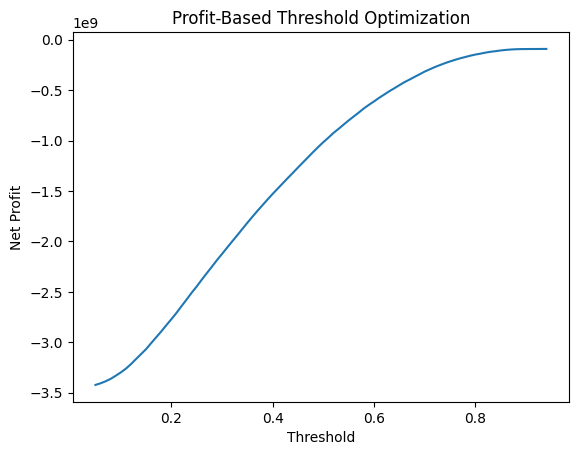

In [27]:
import matplotlib.pyplot as plt

plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Net Profit")
plt.title("Profit-Based Threshold Optimization")
plt.show()


In [28]:
from sklearn.metrics import confusion_matrix

best_preds = (proba > best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, best_preds).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


TN: 56553
FP: 1
FN: 4943
TP: 6


In [29]:
profits = []

for t in thresholds:
    preds = (proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    net_profit = tp * profit_per_good - fp * loss_per_default
    profits.append(net_profit)

best_idx = np.argmax(profits)

best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print("Best Threshold:", best_threshold)
print("Best Profit:", best_profit)


Best Threshold: 0.9400000000000002
Best Profit: 13000


In [30]:
profit_per_good = 15000
loss_per_default = 60000

# Expected value per borrower
ev = (1 - proba) * profit_per_good - proba * loss_per_default

# Approve only if EV > 0
approve = ev > 0

approved_count = approve.sum()

# Calculate total projected profit
total_profit = ev[approve].sum()

print("Approved:", approved_count)
print("Projected Profit:", round(total_profit))


Approved: 11181
Projected Profit: 53271756


In [31]:
approval_rate = approved_count / len(proba)
print("Approval Rate:", round(approval_rate * 100,2), "%")


Approval Rate: 18.18 %


In [32]:
avg_ev = total_profit / approved_count
print("Average EV per Approved Borrower:", round(avg_ev))


Average EV per Approved Borrower: 4764


In [33]:
ev_all = ((1 - proba) * profit_per_good - proba * loss_per_default).sum()
print("Profit if approve everyone:", round(ev_all))


Profit if approve everyone: -941705152


In [34]:
print("----- Portfolio Summary -----")
print("Total Applicants:", len(proba))
print("Approved Applicants:", approved_count)
print("Approval Rate:", round(approval_rate * 100,2), "%")
print("Projected Profit (EV Strategy):", round(total_profit))
print("Profit If Approve All:", round(ev_all))


----- Portfolio Summary -----
Total Applicants: 61503
Approved Applicants: 11181
Approval Rate: 18.18 %
Projected Profit (EV Strategy): 53271756
Profit If Approve All: -941705152


In [35]:
app_test = app.loc[X_test.index].copy()
app_test["PD"] = proba
app_test["EV"] = ev
app_test["Approved"] = approve

band_profit = app_test.groupby("risk_band")["EV"].sum()

print("Profit by Risk Band:")
print(band_profit)


Profit by Risk Band:
risk_band
High Risk    -500172448.0
Near Prime   -170670720.0
Prime          42930608.0
Subprime     -313792608.0
Name: EV, dtype: float32


In [36]:
stress_pd = np.minimum(proba * 2, 1)

stress_ev = (1 - stress_pd) * profit_per_good - stress_pd * loss_per_default

stress_approve = stress_ev > 0
stress_profit = stress_ev[stress_approve].sum()

print("Stress Scenario Profit:", round(stress_profit))


Stress Scenario Profit: 9944590


In [37]:
model.save_model("credit_model.json")


In [38]:
import joblib
joblib.dump(features, "feature_columns.pkl")


['feature_columns.pkl']